# 01 -- Units, dimensions, and dimensional analysis

| question | answer |
|---|---|
| What physics problem? | Is a candidate formula physically possible? |
| What mathematics? | Vector space of exponents over the seven SI base quantities. |
| What algorithm? | Add exponents on multiply; require equality on add (dimensional checking). |
| What software? | physkit.units.Dimension and Quantity; SymPy for symbolic checks. |
| What experiment? | Every measured quantity carries a unit set by its instrument. |
| What engineering application? | An ADC least-significant bit is a voltage; scaling must preserve units. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
import physkit
from physkit import constants as C, units as U, linalg as la
from physkit.plotting import use_style
use_style()
torch = physkit.optional_torch()            # None if PyTorch is unavailable; NumPy stays authoritative
sp.init_printing()
print("physkit", physkit.__version__, "| numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

physkit 0.1.0 | numpy 2.4.6 | torch: absent (optional)


## English explanation

Every physical quantity is a number times a unit. The unit encodes a **dimension** -- a product
of powers of the seven SI base quantities (length, mass, time, current, temperature, amount, luminous
intensity). A valid equation is dimensionally homogeneous: both sides carry the same dimension, and
only same-dimension quantities may be added. Dimensional analysis rejects impossible formulas before
any number is computed and often reveals the form of a law up to a constant.

Subject-verb-object: the instrument sets the unit; the dimension constrains the formula; the check
rejects the impossible.

## Mathematical derivation

Write a quantity's dimension as the exponent vector
$\mathbf{d}=(a_L,a_M,a_T,a_I,a_K,a_N,a_J)$. Multiplication of quantities adds these vectors; raising
to a power scales the vector; addition is defined only when the vectors are equal. This is exactly a
vector space over the rationals, and `physkit.units.Dimension` implements it. Energy, for example,
is force times length, i.e. $\mathbf{d}_E=(2,1,-2,0,0,0,0)$: $\mathrm{J}=\mathrm{kg\,m^2\,s^{-2}}$.

## Dimensions and SI units

In [2]:
print("ENERGY   =", U.ENERGY)
print("FORCE    =", U.FORCE)
print("VOLTAGE  =", U.VOLTAGE)
assert U.ENERGY == U.MASS * U.LENGTH**2 / U.TIME**2
assert U.VOLTAGE == U.ENERGY / U.CHARGE
# Planck * frequency is an energy; h/p is a length (de Broglie)
h = U.Quantity(C.H, U.ACTION)
print("h f  dimension:", (h * U.Quantity(1.0, U.FREQUENCY)).dim, "(expected ENERGY)")
print("h/p  dimension:", (h / U.Quantity(1.0, U.MASS * U.VELOCITY)).dim, "(expected LENGTH)")

ENERGY   = L^2 M^1 T^-2
FORCE    = L^1 M^1 T^-2
VOLTAGE  = L^2 M^1 T^-3 I^-1
h f  dimension: L^2 M^1 T^-2 (expected ENERGY)
h/p  dimension: L^1 (expected LENGTH)


## SymPy derivation

SymPy can carry symbolic base-dimension factors and confirm homogeneity. We verify the photon
relation $E=hc/\lambda$ is an energy and the diffraction-limit angle $\theta\sim\lambda/D$ is
dimensionless, symbolically.

In [3]:
L, M, T = sp.symbols('L M T', positive=True)
dim = {"h": M*L**2/T, "c": L/T, "lam": L, "E": M*L**2/T**2}
lhs = dim["E"]
rhs = dim["h"] * dim["c"] / dim["lam"]
assert sp.simplify(lhs - rhs) == 0
print("E = h c / lambda is dimensionally an energy:", sp.simplify(lhs/rhs), "(ratio = 1)")
assert sp.simplify(dim["lam"] / dim["lam"]) == 1     # theta ~ lambda/D dimensionless
print("theta ~ lambda / D is dimensionless")

E = h c / lambda is dimensionally an energy: 1 (ratio = 1)
theta ~ lambda / D is dimensionless


## NumPy implementation

With the dimensions confirmed, compute the numbers. The photon energy of light across the
visible band, in joules and electron-volts, via $E=hc/\lambda$.

In [4]:
lam_nm = np.array([400, 450, 500, 550, 600, 650, 700.0])
lam = lam_nm * C.NM
E_J = C.H * C.C / lam
E_eV = E_J / C.E
print("400 nm ->", round(float(E_eV[0]), 3), "eV ;  700 nm ->", round(float(E_eV[-1]), 3), "eV")

400 nm -> 3.1 eV ;  700 nm -> 1.771 eV


## Pandas tables

The SI constant set and the visible-band photon energies as tables (the constants come straight
from `physkit.constants`).

In [5]:
print(C.table().to_string(index=False))
print()
df = pd.DataFrame({"wavelength_nm": lam_nm, "energy_eV": np.round(E_eV, 3),
                   "frequency_THz": np.round(C.C / lam / 1e12, 1)})
print(df.to_string(index=False))

symbol     value_SI  unit             description
     c 2.997925e+08   m/s          speed of light
     h 6.626070e-34   J s         Planck constant
  hbar 1.054572e-34   J s reduced Planck constant
     e 1.602177e-19     C       elementary charge
   k_B 1.380649e-23   J/K      Boltzmann constant
   N_A 6.022141e+23 1/mol       Avogadro constant
  eps0 8.854188e-12   F/m     vacuum permittivity
   m_e 9.109384e-31    kg           electron mass
   m_p 1.672622e-27    kg             proton mass
    a0 5.291772e-11     m             Bohr radius
    Ry 1.360569e+01    eV          Rydberg energy
  mu_B 9.274010e-24   J/T           Bohr magneton
 alpha 7.297353e-03     1 fine-structure constant

 wavelength_nm  energy_eV  frequency_THz
         400.0      3.100          749.5
         450.0      2.755          666.2
         500.0      2.480          599.6
         550.0      2.254          545.1
         600.0      2.066          499.7
         650.0      1.907          461.2
         700

## Matplotlib plots

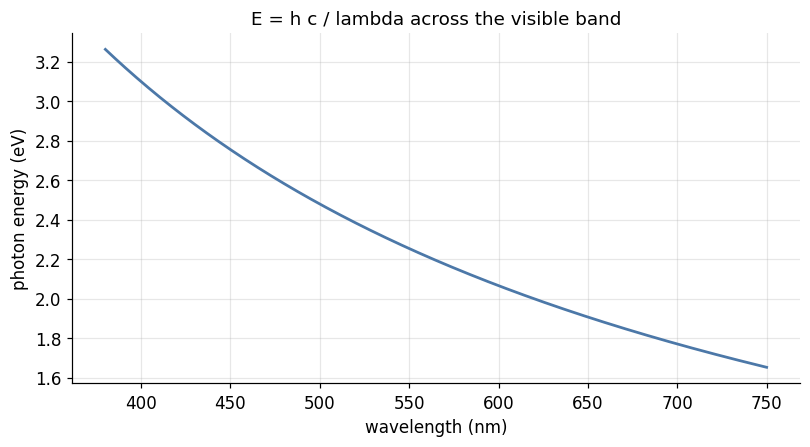

In [6]:
lam_c = np.linspace(380, 750, 400)
plt.figure()
plt.plot(lam_c, C.H * C.C / (lam_c * C.NM) / C.E)
plt.xlabel("wavelength (nm)"); plt.ylabel("photon energy (eV)")
plt.title("E = h c / lambda across the visible band")
plt.tight_layout(); plt.show()

## PyTorch (optional)

In [7]:
if torch is not None:
    lam_t = torch.tensor(lam, dtype=torch.float64)
    E_t = C.H * C.C / lam_t / C.E
    print("torch photon energies (eV):", [round(v, 3) for v in E_t.tolist()])
else:
    print("PyTorch absent -- the NumPy energies above are authoritative.")

PyTorch absent -- the NumPy energies above are authoritative.


## Exercises

1. Use dimensional analysis to recover the form of the gravitational period of a pendulum,
   $T\sim\sqrt{L/g}$, from the variables $L$ (length) and $g$ (acceleration).
2. Show with `physkit.units` that the fine-structure constant $\alpha=e^2/(4\pi\epsilon_0\hbar c)$ is
   dimensionless.
3. An ADC has full-scale $2.0\,\mathrm{V}$ and 12 bits. Compute the least-significant-bit voltage and
   confirm it has the dimension of voltage; express it in microvolts.

## Engineering applications

A **detector** outputs a voltage; an **ADC** maps that voltage to an integer code; the
least-significant bit $V_\text{LSB}=V_\text{FS}/2^{N}$ is itself a voltage, so any fixed-point scaling
in **firmware** must track the unit or the reconstructed physical value will be wrong by a power of
ten. Dimensional checking is the cheapest possible test of a signal-chain formula, and it runs before
any hardware exists.

Summary (subject-verb-object): the instrument sets units; the dimension vector constrains the law;
`physkit.units` rejects the inconsistent; the engineer scales without losing meaning.